# Task 1: Imrpove the CNN model from previous worksheet

In [2]:
# Import Libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
train_dir = "/content/drive/MyDrive/AIandML/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AIandML/FruitinAmazon/test"

In [4]:
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

if not class_names:
    print("No class directories found!")
else:
    print(f"Found {len(class_names)} classes:", class_names)

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [5]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, UnidentifiedImageError):
            corrupted_images.append(img_path)

if corrupted_images:
    print("Corrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


In [6]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png','.jpg','.jpeg'))]
    class_counts[class_name] = len(images)

print("\nClass Distribution:")
for k, v in class_counts.items():
    print(k, ":", v)


Class Distribution:
acai : 15
cupuacu : 15
graviola : 15
guarana : 15
pupunha : 15
tucuma : 15


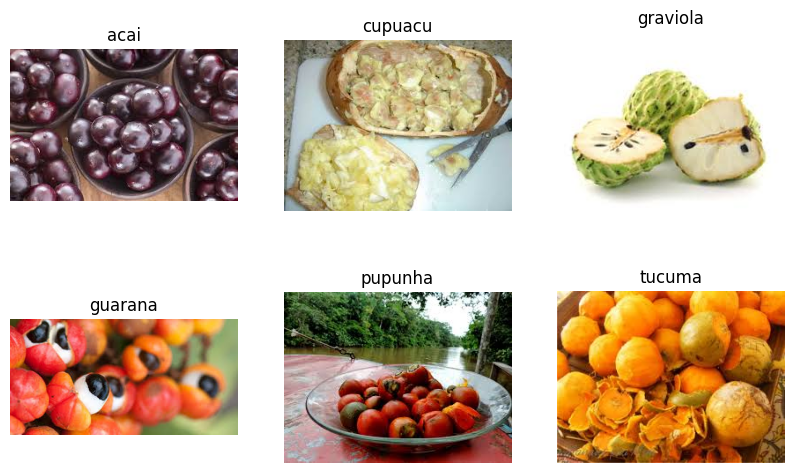

In [7]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)
    if images:
        img_path = os.path.join(class_path, random.choice(images))
        selected_images.append(img_path)
        selected_labels.append(class_name)

plt.figure(figsize=(10,6))
for i in range(len(selected_images)):
    plt.subplot(2,3,i+1)
    img = mpimg.imread(selected_images[i])
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")
plt.show()

Data Generation and Preprocessing

In [8]:
image_size = (224, 224)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [9]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


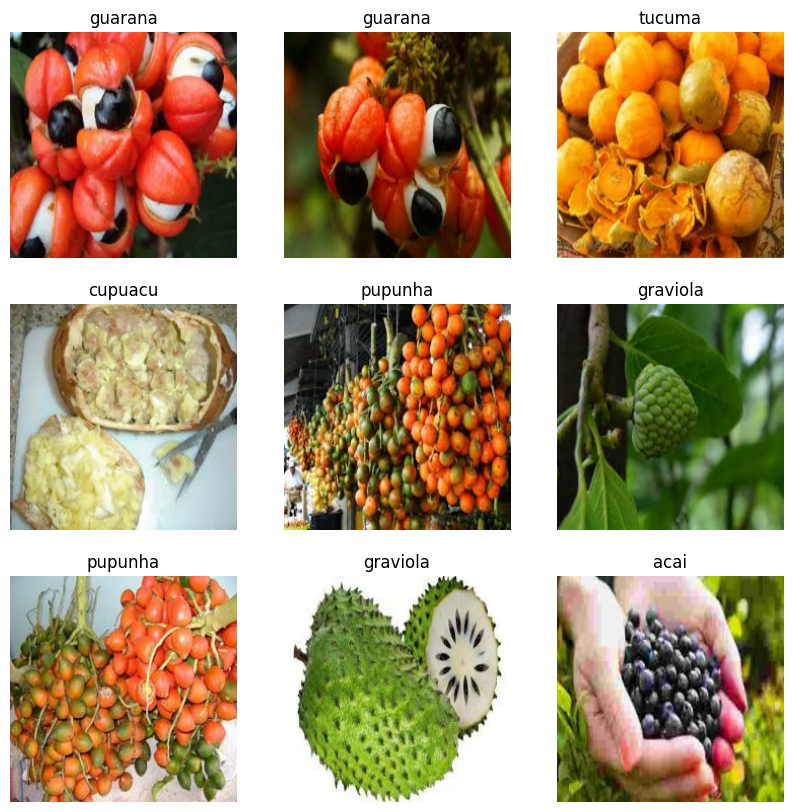

In [10]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Data Augmentation

In [11]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

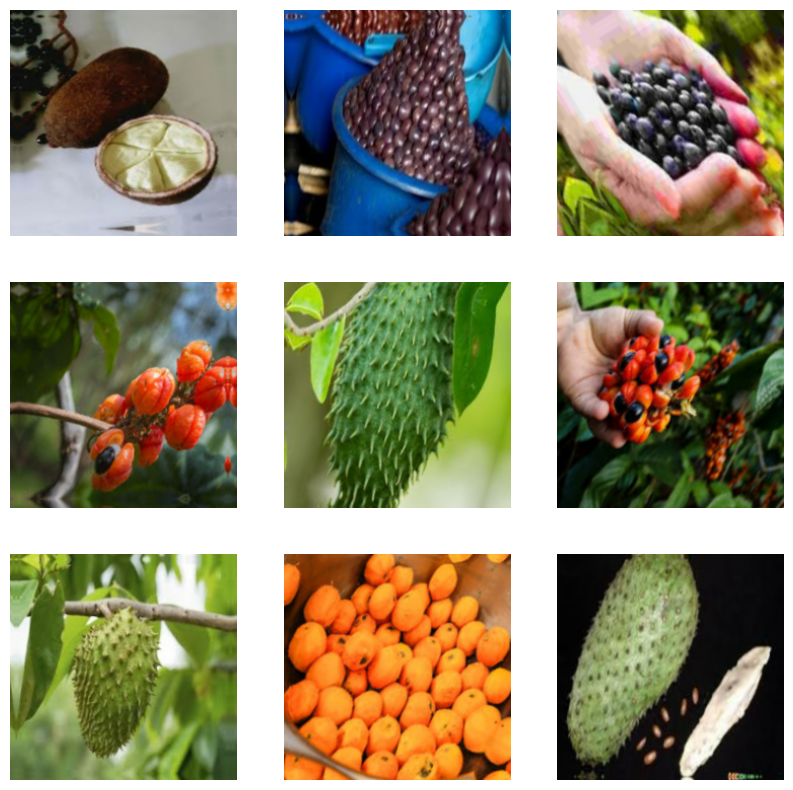

In [12]:
plt.figure(figsize=(10,10))
for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")
plt.show()

Build CNN Model (Improved)

In [13]:
model = Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Rescaling(1./255),

    Conv2D(32,(3,3),padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64,(3,3),padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128,(3,3),padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Flatten(),

    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 6s/step - accuracy: 0.2222 - loss: 2.1607 - val_accuracy: 0.1111 - val_loss: 1.8564
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.5556 - loss: 1.2610 - val_accuracy: 0.1667 - val_loss: 1.9556
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.6111 - loss: 0.9607 - val_accuracy: 0.1667 - val_loss: 2.0349
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.6250 - loss: 0.9498 - val_accuracy: 0.1667 - val_loss: 1.9570
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.6667 - loss: 0.8323 - val_accuracy: 0.2778 - val_loss: 1.9083
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.7083 - loss: 0.7368 - val_accuracy: 0.1111 - val_loss: 2.0172
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.8889 - loss: 0.5209 - val_accuracy: 0.1111 - val_loss: 2.2123
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 8s/step - accuracy: 0.7222 - loss: 0.7125 - val_accuracy: 0.1111 - val_loss: 2.4027
Epoch 9/

In [16]:
cnn_loss, cnn_acc = model.evaluate(val_ds)
print("CNN Accuracy:", cnn_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step - accuracy: 0.1111 - loss: 3.0201
CNN Accuracy: 0.1111111119389534


In [17]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.11      1.00      0.20         2
    graviola       0.00      0.00      0.00         3
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.11        18
   macro avg       0.02      0.17      0.03        18
weighted avg       0.01      0.11      0.02        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Task 2: Transfer Learning using VGG16




In [18]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [19]:
for layer in base_model.layers:
    layer.trainable = False

In [20]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

In [21]:
from tensorflow.keras.models import Model

vgg_model = Model(inputs=base_model.input, outputs=outputs)

In [22]:
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 69s 23s/step - accuracy: 0.1250 - loss: 10.3845 - val_accuracy: 0.1667 - val_loss: 4.2391
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 22s/step - accuracy: 0.2778 - loss: 6.3864 - val_accuracy: 0.3333 - val_loss: 3.4413
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 23s/step - accuracy: 0.5000 - loss: 3.2218 - val_accuracy: 0.5556 - val_loss: 2.5034
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 68s 24s/step - accuracy: 0.6806 - loss: 2.1545 - val_accuracy: 0.5556 - val_loss: 2.3855
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 19s/step - accuracy: 0.7639 - loss: 1.2601 - val_accuracy: 0.5000 - val_loss: 2.4727
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 22s/step - accuracy: 0.7778 - loss: 1.5245 - val_accuracy: 0.5556 - val_loss: 2.5649
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 95s 25s/step - accuracy: 0.7778 - loss: 0.9956 - val_accuracy: 0.5556 - val_loss: 2.4218
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 70s 22s/step - accuracy: 0.8611 - loss: 0.4609 - val_accuracy: 0.6111 - val_loss: 2.1240

In [24]:
vgg_loss, vgg_acc = vgg_model.evaluate(val_ds)
print("VGG16 Accuracy:", vgg_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.6111 - loss: 2.2553
VGG16 Accuracy: 0.6111111044883728


In [25]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = vgg_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.50      0.50      0.50         2
    graviola       1.00      1.00      1.00         3
     guarana       0.80      0.80      0.80         5
     pupunha       0.50      0.25      0.33         4
      tucuma       0.33      0.67      0.44         3

    accuracy                           0.61        18
   macro avg       0.52      0.54      0.51        18
weighted avg       0.61      0.61      0.59        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
# Comparison
print("CNN Accuracy:", cnn_acc)
print("VGG Accuracy:", vgg_acc)

CNN Accuracy: 0.1111111119389534
VGG Accuracy: 0.6111111044883728
